# SECTION 2: CNN-LSTM MODEL TRAINING

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, Adamax, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

# ========== SETUP ==========
SAMPLE_RATE = 22050
BATCH_SIZE = 32
NUM_CLASSES = 5

# ========== LOAD & PREPARE DATA ==========
X = np.load("X_hybrid_balanced.npy")
y = np.load("y_hybrid_balanced.npy")

X = X / np.max(X)
X = X[..., np.newaxis]
y_cat = to_categorical(y, num_classes=NUM_CLASSES)
class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]

# Function to allow split tuning
def split_data(split_ratio=(0.8, 0.1, 0.1)):
    X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
    val_fraction = split_ratio[1] / (split_ratio[0] + split_ratio[1])
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_fraction, stratify=y_temp.argmax(1), random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# ========== ATTENTION LAYER ==========
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# ========== MODEL ==========
def build_cnn_lstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)

# ========== UNIVERSAL RUNNER FUNCTION ==========
def run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, patience=5, batch_size=16, split_ratio=(0.8, 0.1, 0.1), model_save_path="best_model.keras"):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(split_ratio=split_ratio)
    
    model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=NUM_CLASSES)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    checkpoint = ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop, checkpoint], verbose=1)

    best_model = tf.keras.models.load_model(model_save_path, custom_objects={"AttentionLayer": AttentionLayer})

    train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Final Training Accuracy: {train_acc * 100:.2f}%")
    print(f"🧪 Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = best_model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_acc, val_acc, test_acc



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
794/794 [==============================] - ETA: 0s - loss: 1.5359 - accuracy: 0.2752
Epoch 1: val_accuracy improved from -inf to 0.37406, saving model to best_model.keras
794/794 [==============================] - 403s 493ms/step - loss: 1.5359 - accuracy: 0.2752 - val_loss: 1.4048 - val_accuracy: 0.3741
Epoch 2/60
794/794 [==============================] - ETA: 0s - loss: 1.2814 - accuracy: 0.4403
Epoch 2: val_accuracy improved from 0.37406 to 0.48111, saving model to best_model.keras
794/794 [==============================] - 377s 474ms/step - loss: 1.2814 - accuracy: 0.4403 - val_loss: 1.1700 - val_accuracy: 0.4811
Epoch 3/60
794/794 [==============================] - ETA: 0s - loss: 0.9597 - accuracy: 0.5981
Epoch 3: val_accuracy improved from 0.48111 to 0.65113, saving model to best_model.keras
794/794 [==============================] - 367s 462ms/step - loss: 0.9597 - accuracy: 0.5981 - val_loss: 0.8576 -

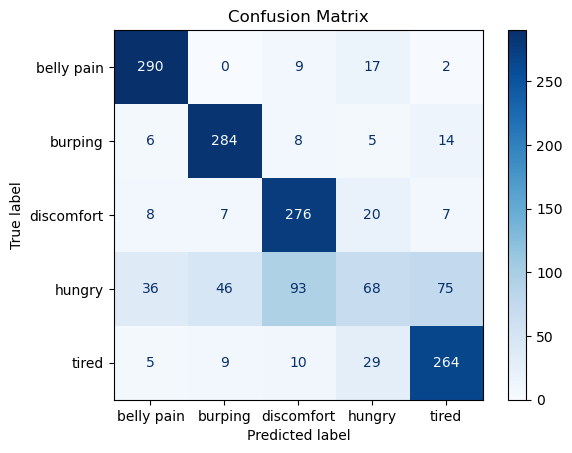

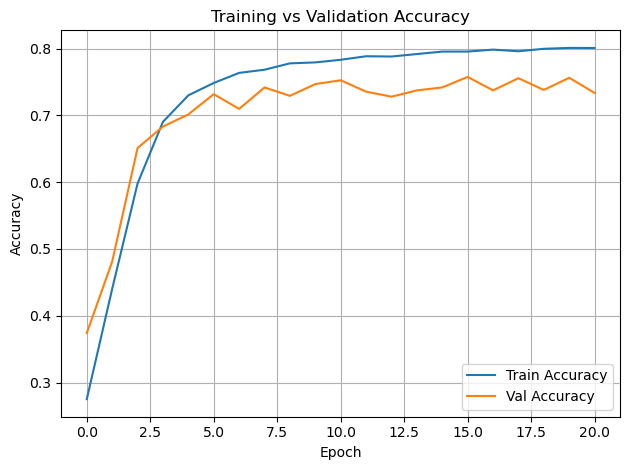

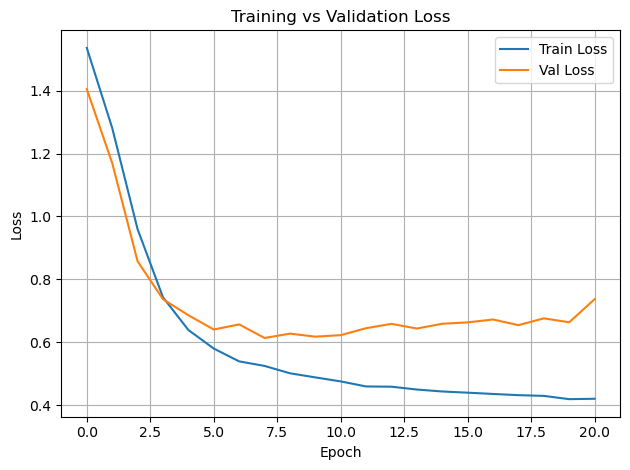

(0.8239924311637878, 0.757556676864624, 0.744332492351532)

In [2]:

print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam", 
    lr=0.001, 
    epochs=60,
    split_ratio=(0.8, 0.1, 0.1)
)


In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.15, 0.15)
)



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15
Epoch 1/60
695/695 [==============================] - ETA: 0s - loss: 1.5723 - accuracy: 0.2497
Epoch 1: val_accuracy improved from -inf to 0.32662, saving model to best_model.keras
695/695 [==============================] - 405s 564ms/step - loss: 1.5723 - accuracy: 0.2497 - val_loss: 1.4582 - val_accuracy: 0.3266
Epoch 2/60
695/695 [==============================] - ETA: 0s - loss: 1.3844 - accuracy: 0.3731
Epoch 2: val_accuracy improved from 0.32662 to 0.40638, saving model to best_model.keras
695/695 [==============================] - 354s 510ms/step - loss: 1.3844 - accuracy: 0.3731 - val_loss: 1.3454 - val_accuracy: 0.4064
Epoch 3/60
555/695 [======================>.......] - ETA: 1:22 - loss: 1.1794 - accuracy: 0.4946

In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.7, 0.20, 0.10)
)


In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | SGD | 0.01 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="SGD",
    lr=0.01,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM |Adam | 0.0005 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0005,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)

In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.0001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)

In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 20 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=20,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)

In [ ]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=40,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)

In [ ]:

from copy import deepcopy
import os
import pandas as pd
import json

best_val_acc = 0.0
best_model_state = None
best_optimizer_name = ""
results_list = []


In [ ]:

# ================= Final Save Step =================
# Save the best CNN-LSTM model
best_model_path = f"best_cnn_lstm_model_{best_optimizer_name.lower()}.pth"
torch.save(best_model_state, best_model_path)
print(f"✅ Best CNN-LSTM model saved as {best_model_path} with val acc = {best_val_acc:.4f}")

# Save all results to CSV
df_all_results = pd.DataFrame(results_list)
df_all_results.to_csv("cnn_lstm_training_results.csv", index=False)
print("📁 All training results saved to cnn_lstm_training_results.csv")

# Save all results to JSON
with open("cnn_lstm_training_results.json", "w") as json_file:
    json.dump(results_list, json_file, indent=4)
print("📁 All training results saved to cnn_lstm_training_results.json")
